PLACEMENT STATUS DISTRIBUTION
PlacementStatus
Not Placed    100
Placed        100
Name: count, dtype: int64

TRAINING CLASSES
PlacementStatus
Not Placed    80
Placed        80
Name: count, dtype: int64

VALIDATION CLASSES
PlacementStatus
Not Placed    20
Placed        20
Name: count, dtype: int64


ADABOOST
Validation Accuracy: 0.925
Training Time: 0.2038 seconds

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.90      0.95      0.93        20
      Placed       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



GRADIENT BOOSTING
Validation Accuracy: 0.85
Training Time: 0.1708 seconds

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.85      0.85      0.85        20
      Placed       0.85      0.85      0.85        20

    accuracy       

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


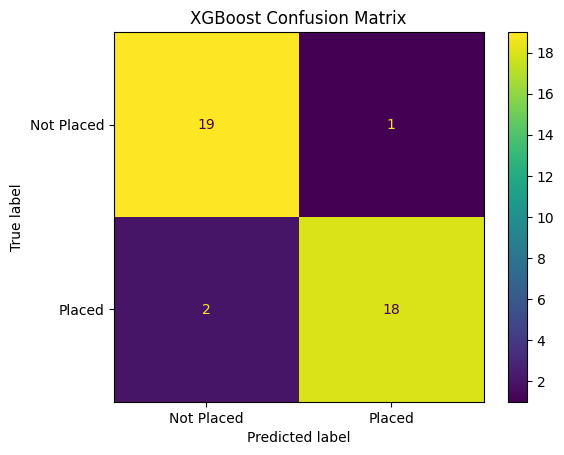



SHAP FEATURE IMPORTANCE


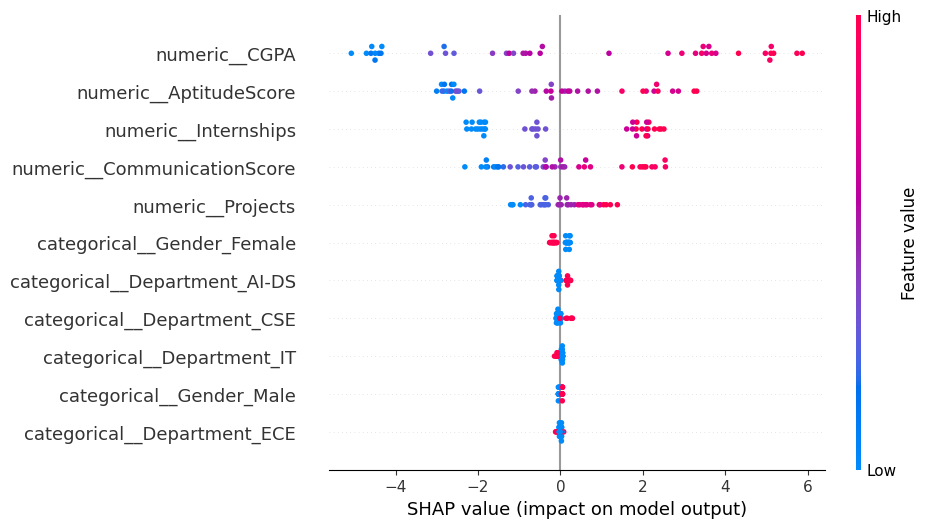



XGBOOST FEATURE IMPORTANCE
                          Feature  Importance
0                   numeric__CGPA    0.245304
6     categorical__Department_CSE    0.129012
3            numeric__Internships    0.122218
1          numeric__AptitudeScore    0.107581
2     numeric__CommunicationScore    0.091421
7     categorical__Department_ECE    0.063874
4               numeric__Projects    0.062159
5   categorical__Department_AI-DS    0.056976
8      categorical__Department_IT    0.056874
9      categorical__Gender_Female    0.034500
10       categorical__Gender_Male    0.030081


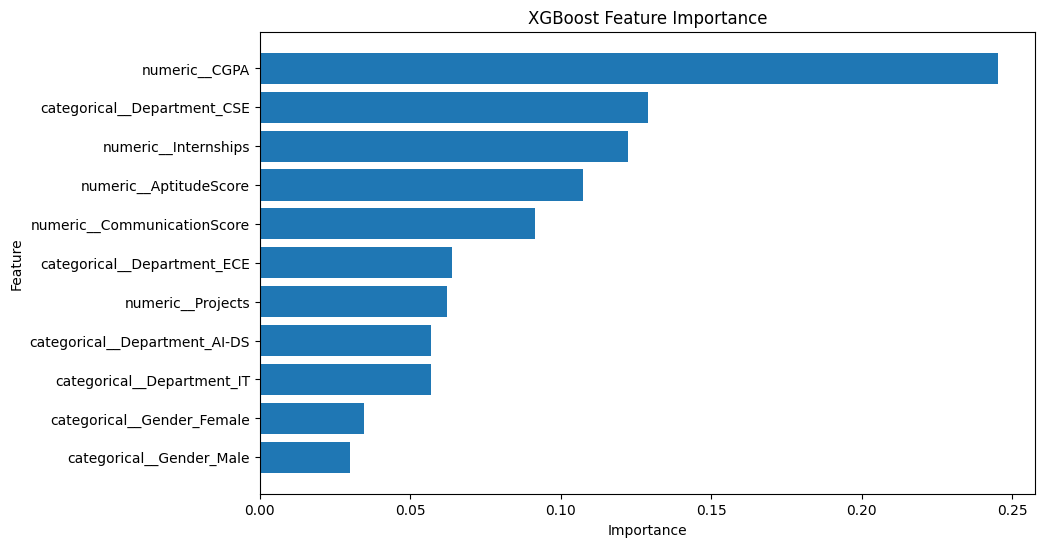



BOOSTING VERSION 1
Version 1 Accuracy: 0.95


BOOSTING VERSION 2
Version 2 Accuracy: 0.925


VERSION 1 VS VERSION 2
       Version  Validation Accuracy  Training Time
0  Boosting V1                0.950       0.207998
1  Boosting V2                0.925       0.611103


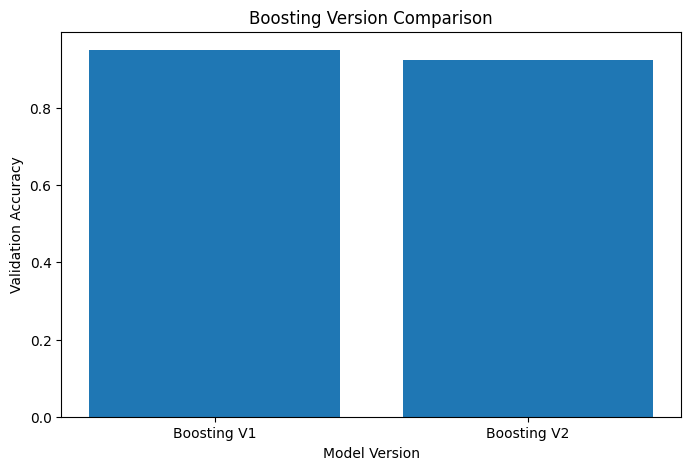

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(




BOOSTING BENCHMARK RESULTS
            Model  Validation Accuracy  Training Time
         AdaBoost                0.925       0.305091
          XGBoost                0.925       0.110948
         LightGBM                0.925       0.023693
Gradient Boosting                0.850       0.211592


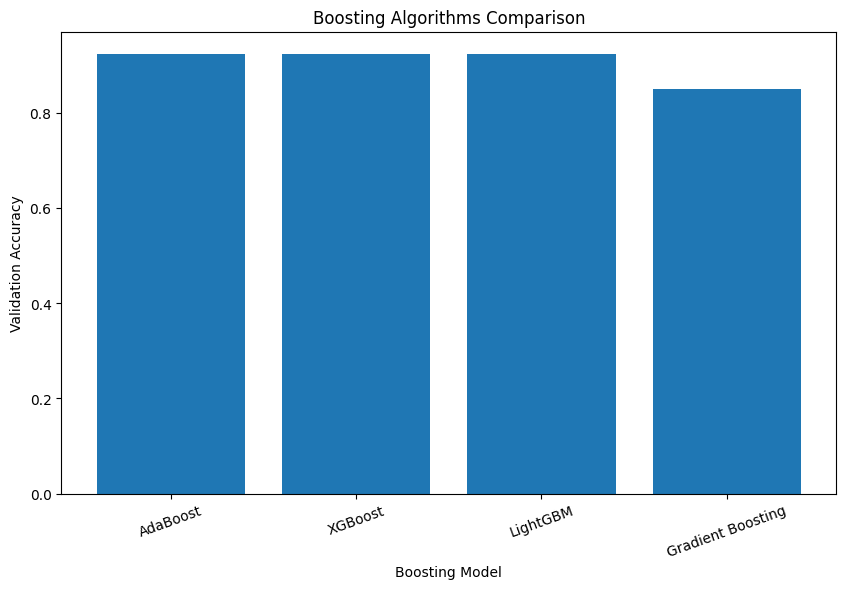



SESSION 8 COMPLETED SUCCESSFULLY
AdaBoost Accuracy: 0.925
Gradient Boosting Accuracy: 0.85
XGBoost Accuracy: 0.925
XGBoost Early Stopping Accuracy: 0.925
LightGBM Accuracy: 0.925

All Boosting Algorithms Executed Successfully.


In [101]:
# ============================================================
# SESSION 8 - BOOSTING ALGORITHMS
# AdaBoost | Gradient Boosting | XGBoost | LightGBM | SHAP
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL REQUIRED LIBRARIES
# ------------------------------------------------------------
!pip install -q xgboost lightgbm shap

# ------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

# ------------------------------------------------------------
# 3. CREATE STUDENT DATASET
# ------------------------------------------------------------
np.random.seed(42)

n = 200

df = pd.DataFrame({
    "CGPA": np.round(np.random.uniform(5.5, 9.8, n), 2),
    "AptitudeScore": np.random.randint(40, 100, n),
    "CommunicationScore": np.random.randint(40, 100, n),
    "Internships": np.random.randint(0, 4, n),
    "Projects": np.random.randint(1, 6, n),
    "Department": np.random.choice(
        ["CSE", "IT", "AI-DS", "ECE"],
        n
    ),
    "Gender": np.random.choice(
        ["Male", "Female"],
        n
    )
})

# ------------------------------------------------------------
# 4. CREATE PLACEMENT SCORE
# ------------------------------------------------------------
df["PlacementScore"] = (
    df["CGPA"] * 10
    + df["AptitudeScore"] * 0.5
    + df["CommunicationScore"] * 0.3
    + df["Internships"] * 5
    + df["Projects"] * 2
)

# ------------------------------------------------------------
# 5. CREATE BALANCED TARGET
# ------------------------------------------------------------
# Median is used so both classes are available.
threshold = df["PlacementScore"].median()

df["PlacementStatus"] = np.where(
    df["PlacementScore"] >= threshold,
    "Placed",
    "Not Placed"
)

# ------------------------------------------------------------
# 6. DISPLAY TARGET DISTRIBUTION
# ------------------------------------------------------------
print("================================================")
print("PLACEMENT STATUS DISTRIBUTION")
print("================================================")

print(df["PlacementStatus"].value_counts())

# ------------------------------------------------------------
# 7. DEFINE FEATURES
# ------------------------------------------------------------
feature_cols = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects",
    "Department",
    "Gender"
]

X = df[feature_cols]
y = df["PlacementStatus"]

# ------------------------------------------------------------
# 8. TRAIN / VALIDATION SPLIT
# ------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n================================================")
print("TRAINING CLASSES")
print("================================================")
print(y_train.value_counts())

print("\n================================================")
print("VALIDATION CLASSES")
print("================================================")
print(y_val.value_counts())

# ------------------------------------------------------------
# 9. CONVERT TARGET TO BINARY FOR XGBOOST
# ------------------------------------------------------------
y_train_binary = (
    y_train == "Placed"
).astype(int)

y_val_binary = (
    y_val == "Placed"
).astype(int)

# ------------------------------------------------------------
# 10. PREPROCESSING
# ------------------------------------------------------------
numeric_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

categorical_features = [
    "Department",
    "Gender"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# ============================================================
# 11. ADABOOST
# ============================================================

print("\n\n================================================")
print("ADABOOST")
print("================================================")

ada_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )
    )
])

start_time = time.time()

ada_model.fit(
    X_train,
    y_train
)

ada_time = time.time() - start_time

ada_pred = ada_model.predict(X_val)

ada_accuracy = accuracy_score(
    y_val,
    ada_pred
)

print("Validation Accuracy:", round(ada_accuracy, 4))
print("Training Time:", round(ada_time, 4), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        ada_pred,
        zero_division=0
    )
)

# ============================================================
# 12. GRADIENT BOOSTING CLASSIFIER
# ============================================================

print("\n\n================================================")
print("GRADIENT BOOSTING")
print("================================================")

gbc_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

start_time = time.time()

gbc_model.fit(
    X_train,
    y_train
)

gbc_time = time.time() - start_time

gbc_pred = gbc_model.predict(X_val)

gbc_accuracy = accuracy_score(
    y_val,
    gbc_pred
)

print("Validation Accuracy:", round(gbc_accuracy, 4))
print("Training Time:", round(gbc_time, 4), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        gbc_pred,
        zero_division=0
    )
)

# ============================================================
# 13. PREPROCESS DATA FOR XGBOOST / SHAP
# ============================================================

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

# ------------------------------------------------------------
# GET FEATURE NAMES
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

# ============================================================
# 14. XGBOOST
# ============================================================

print("\n\n================================================")
print("XGBOOST")
print("================================================")

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_model.fit(
    X_train_processed,
    y_train_binary
)

xgb_time = time.time() - start_time

xgb_pred_binary = xgb_model.predict(
    X_val_processed
)

xgb_pred = np.where(
    xgb_pred_binary == 1,
    "Placed",
    "Not Placed"
)

xgb_accuracy = accuracy_score(
    y_val,
    xgb_pred
)

print("Validation Accuracy:", round(xgb_accuracy, 4))
print("Training Time:", round(xgb_time, 4), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        xgb_pred,
        zero_division=0
    )
)

# ============================================================
# 15. XGBOOST EARLY STOPPING
# ============================================================

print("\n\n================================================")
print("XGBOOST WITH EARLY STOPPING")
print("================================================")

xgb_early = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_early.fit(
    X_train_processed,
    y_train_binary,
    eval_set=[
        (
            X_val_processed,
            y_val_binary
        )
    ],
    verbose=False
)

xgb_early_time = time.time() - start_time

xgb_early_pred_binary = xgb_early.predict(
    X_val_processed
)

xgb_early_pred = np.where(
    xgb_early_pred_binary == 1,
    "Placed",
    "Not Placed"
)

xgb_early_accuracy = accuracy_score(
    y_val,
    xgb_early_pred
)

print(
    "Best Iteration:",
    xgb_early.best_iteration
)

print(
    "Validation Accuracy:",
    round(xgb_early_accuracy, 4)
)

print(
    "Training Time:",
    round(xgb_early_time, 4),
    "seconds"
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        xgb_early_pred,
        zero_division=0
    )
)

# ============================================================
# 16. LIGHTGBM
# ============================================================

print("\n\n================================================")
print("LIGHTGBM")
print("================================================")

lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=15,
    random_state=42,
    verbosity=-1
)

start_time = time.time()

lgb_model.fit(
    X_train_processed,
    y_train_binary
)

lgb_time = time.time() - start_time

lgb_pred_binary = lgb_model.predict(
    X_val_processed
)

lgb_pred = np.where(
    lgb_pred_binary == 1,
    "Placed",
    "Not Placed"
)

lgb_accuracy = accuracy_score(
    y_val,
    lgb_pred
)

print(
    "Validation Accuracy:",
    round(lgb_accuracy, 4)
)

print(
    "Training Time:",
    round(lgb_time, 4),
    "seconds"
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        lgb_pred,
        zero_division=0
    )
)

# ============================================================
# 17. CONFUSION MATRIX - XGBOOST
# ============================================================

print("\n\n================================================")
print("XGBOOST CONFUSION MATRIX")
print("================================================")

cm = confusion_matrix(
    y_val,
    xgb_early_pred,
    labels=["Not Placed", "Placed"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

# ============================================================
# 18. SHAP BEESWARM PLOT
# ============================================================

print("\n\n================================================")
print("SHAP FEATURE IMPORTANCE")
print("================================================")

explainer = shap.TreeExplainer(
    xgb_early
)

shap_values = explainer(
    X_val_processed
)

shap_values.feature_names = feature_names

shap.plots.beeswarm(
    shap_values,
    max_display=15
)

# ============================================================
# 19. FEATURE IMPORTANCE BAR CHART
# ============================================================

print("\n\n================================================")
print("XGBOOST FEATURE IMPORTANCE")
print("================================================")

importance = xgb_early.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

# ============================================================
# 20. BOOSTING VERSION 1
# ============================================================

print("\n\n================================================")
print("BOOSTING VERSION 1")
print("================================================")

gb_v1 = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    )
])

start_time = time.time()

gb_v1.fit(
    X_train,
    y_train
)

v1_time = time.time() - start_time

v1_pred = gb_v1.predict(
    X_val
)

v1_accuracy = accuracy_score(
    y_val,
    v1_pred
)

print(
    "Version 1 Accuracy:",
    round(v1_accuracy, 4)
)

# ============================================================
# 21. BOOSTING VERSION 2
# ============================================================

print("\n\n================================================")
print("BOOSTING VERSION 2")
print("================================================")

gb_v2 = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )
    )
])

start_time = time.time()

gb_v2.fit(
    X_train,
    y_train
)

v2_time = time.time() - start_time

v2_pred = gb_v2.predict(
    X_val
)

v2_accuracy = accuracy_score(
    y_val,
    v2_pred
)

print(
    "Version 2 Accuracy:",
    round(v2_accuracy, 4)
)

# ============================================================
# 22. VERSION 1 VS VERSION 2
# ============================================================

version_df = pd.DataFrame({
    "Version": [
        "Boosting V1",
        "Boosting V2"
    ],
    "Validation Accuracy": [
        v1_accuracy,
        v2_accuracy
    ],
    "Training Time": [
        v1_time,
        v2_time
    ]
})

print("\n\n================================================")
print("VERSION 1 VS VERSION 2")
print("================================================")

print(version_df)

plt.figure(figsize=(8, 5))

plt.bar(
    version_df["Version"],
    version_df["Validation Accuracy"]
)

plt.xlabel("Model Version")
plt.ylabel("Validation Accuracy")
plt.title(
    "Boosting Version Comparison"
)

plt.show()

# ============================================================
# 23. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
):

    results = []

    # -------------------------
    # AdaBoost
    # -------------------------

    ada = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            AdaBoostClassifier(
                n_estimators=100,
                learning_rate=0.5,
                random_state=42
            )
        )
    ])

    start = time.time()

    ada.fit(
        X_train,
        y_train
    )

    train_time = time.time() - start

    pred = ada.predict(
        X_val
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    results.append({
        "Model": "AdaBoost",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })

    # -------------------------
    # Gradient Boosting
    # -------------------------

    gbc = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ])

    start = time.time()

    gbc.fit(
        X_train,
        y_train
    )

    train_time = time.time() - start

    pred = gbc.predict(
        X_val
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    results.append({
        "Model": "Gradient Boosting",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })

    # -------------------------
    # XGBoost
    # -------------------------

    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    start = time.time()

    xgb.fit(
        X_train_processed,
        y_train_binary
    )

    train_time = time.time() - start

    pred_binary = xgb.predict(
        X_val_processed
    )

    pred = np.where(
        pred_binary == 1,
        "Placed",
        "Not Placed"
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    results.append({
        "Model": "XGBoost",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })

    # -------------------------
    # LightGBM
    # -------------------------

    lgb = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        num_leaves=15,
        random_state=42,
        verbosity=-1
    )

    start = time.time()

    lgb.fit(
        X_train_processed,
        y_train_binary
    )

    train_time = time.time() - start

    pred_binary = lgb.predict(
        X_val_processed
    )

    pred = np.where(
        pred_binary == 1,
        "Placed",
        "Not Placed"
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    results.append({
        "Model": "LightGBM",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })

    return pd.DataFrame(results).sort_values(
        "Validation Accuracy",
        ascending=False
    ).reset_index(drop=True)


# ============================================================
# 24. RUN BOOSTING BENCHMARK
# ============================================================

benchmark_results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

print("\n\n================================================")
print("BOOSTING BENCHMARK RESULTS")
print("================================================")

print(
    benchmark_results.to_string(index=False)
)

# ============================================================
# 25. FINAL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    benchmark_results["Model"],
    benchmark_results["Validation Accuracy"]
)

plt.xlabel("Boosting Model")
plt.ylabel("Validation Accuracy")
plt.title(
    "Boosting Algorithms Comparison"
)

plt.xticks(rotation=20)

plt.show()

# ============================================================
# 26. FINAL OUTPUT
# ============================================================

print("\n\n================================================")
print("SESSION 8 COMPLETED SUCCESSFULLY")
print("================================================")

print("AdaBoost Accuracy:",
      round(ada_accuracy, 4))

print("Gradient Boosting Accuracy:",
      round(gbc_accuracy, 4))

print("XGBoost Accuracy:",
      round(xgb_accuracy, 4))

print("XGBoost Early Stopping Accuracy:",
      round(xgb_early_accuracy, 4))

print("LightGBM Accuracy:",
      round(lgb_accuracy, 4))

print("\nAll Boosting Algorithms Executed Successfully.")